<a href="https://colab.research.google.com/github/xEzIxX/AI-Class/blob/master/week5/wine_DL_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# 다중 분류: 와인의 등급을 예측하는 모델

In [25]:
import pandas as pd
import numpy as np;

file_path = '/content/drive/MyDrive/Colab Notebooks/wine.csv';

# 데이터 읽기
df = pd.read_csv(file_path);

# 상위 5개 행 확인
# print(df.head());
df.head()


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [26]:
# 정답(label) 데이터 설정
# Wine = 와인 등급
y=df['Wine'];
print(y.value_counts());

Wine
2    71
1    59
3    48
Name: count, dtype: int64


In [27]:
# 원-핫 인코딩 : 레이블 간의 순차적인 관계를 끊기 위해서
Y = pd.get_dummies(y).values

In [28]:
# 입력 데이터(feature) 생성
# Wine을 맞춰야하니 해당 등급을 제외
X=df.drop('Wine',axis=1)
X.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [29]:
# 딥러닝 입력을 위해 Numpy로 변환
X = X.values

In [30]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# 모델 구성
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # input_shape 에 숫자로 칼럼 개수 지정 가능
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1], activation="softmax") # Softmax: 모델의 예측 결과를 '0~1 사이의 확률'로 변환하며, 모든 출력의 합을 1(100%)로 맞춤
])

# 컴파일, 학습
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy", # Categorical Crossentropy: '원-핫 인코딩된 정답'과 모델이 예측한 '확률' 사이의 오차를 계산
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.3274 - loss: 1.2843 - val_accuracy: 0.4483 - val_loss: 1.0521
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4867 - loss: 1.0535 - val_accuracy: 0.8276 - val_loss: 0.8623
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6195 - loss: 0.8952 - val_accuracy: 0.8621 - val_loss: 0.7172
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7611 - loss: 0.7356 - val_accuracy: 0.9310 - val_loss: 0.5964
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8319 - loss: 0.6280 - val_accuracy: 1.0000 - val_loss: 0.5002
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8584 - loss: 0.5524 - val_accuracy: 1.0000 - val_loss: 0.4222
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8938 - loss: 0.4547 - val_accuracy: 1.0000 - val_loss: 0.3607
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9204 - loss: 0.3987 - val_accuracy: 1.0000 - val_loss: 0.3079
Epoch 9/50


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


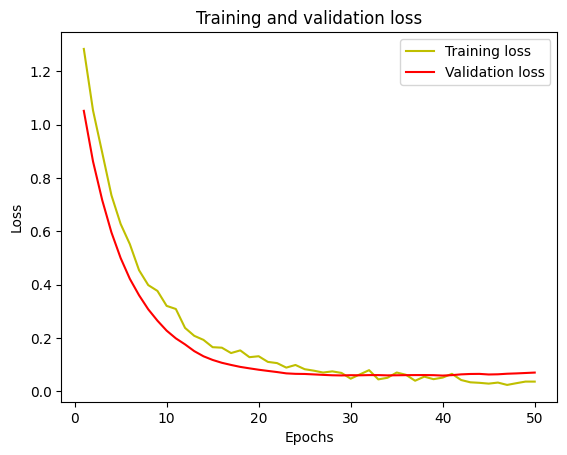

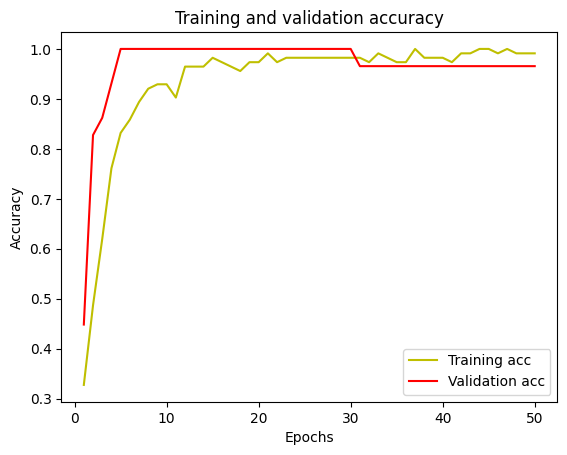

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00         6

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))